In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('Dataset/AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df.isna().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [5]:
df['name'] = df['name'].fillna('Unknown')

In [6]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [7]:
(df['price'] == 0).sum()

np.int64(11)

In [8]:
df = df[df['price'] != 0]

In [9]:
df['occupied_days'] = 365 - df['availability_365']
df['occupancy_rate'] = df['occupied_days'] / 365
df['revpar'] = df['price'] * df['occupancy_rate']

df.sort_values(by='revpar', ascending=False)[
    ['room_type', 'price', 'occupancy_rate', 'availability_365', 'revpar']
].tail(10)

,room_type,price,occupancy_rate,availability_365,revpar
46400,Private room,390,0.0,365,0.0
14877,Entire home/apt,165,0.0,365,0.0
1449,Entire home/apt,135,0.0,365,0.0
46389,Entire home/apt,500,0.0,365,0.0
1453,Entire home/apt,200,0.0,365,0.0
28018,Entire home/apt,150,0.0,365,0.0
46380,Entire home/apt,400,0.0,365,0.0
1458,Entire home/apt,95,0.0,365,0.0
28043,Private room,38,0.0,365,0.0
0,Private room,149,0.0,365,0.0


In [10]:
df[df['minimum_nights'] > 365][
    [
        'name',
        'room_type',
        'price',
        'minimum_nights',
        'number_of_reviews',
        'reviews_per_month',
        'availability_365',
        'neighbourhood',
    ]
]

,name,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,availability_365,neighbourhood
1305,800sqft apartment with huge terrace,Entire home/apt,115,370,6,0.09,365,Bushwick
2854,Unknown,Entire home/apt,400,1000,0,NaN,362,Battery Park City
5767,Prime W. Village location 1 bdrm,Entire home/apt,180,1250,2,0.03,365,Greenwich Village
7355,Beautiful Fully Furnished 1 bed/bth,Entire home/apt,134,500,30,0.57,90,Long Island City
8014,Wonderful Large 1 bedroom,Entire home/apt,75,500,0,NaN,362,Harlem
10829,Brand New Luxury Apt Lease Takeover,Entire home/apt,199,480,0,NaN,365,Long Island City
11193,Zen Room in Crown Heights Brooklyn,Private room,50,500,10,0.22,365,Crown Heights
13404,Historic Designer 2 Bed. Apartment,Entire home/apt,99,999,2,0.07,42,Harlem
14285,Peaceful apartment close to F/G,Private room,45,500,0,NaN,358,Kensington
15946,"Bright Luxury Studio, Central Loc.",Entire home/apt,250,366,0,NaN,365,Midtown


In [11]:
df.groupby('neighbourhood_group')[['revpar','reviews_per_month']].median()

,revpar,reviews_per_month
neighbourhood_group,,
Bronx,32.342466,1.38
Brooklyn,64.498630,0.66
Manhattan,93.000000,0.61
Queens,44.287671,1.21
Staten Island,28.841096,1.41


<function matplotlib.pyplot.show(close=None, block=None)>

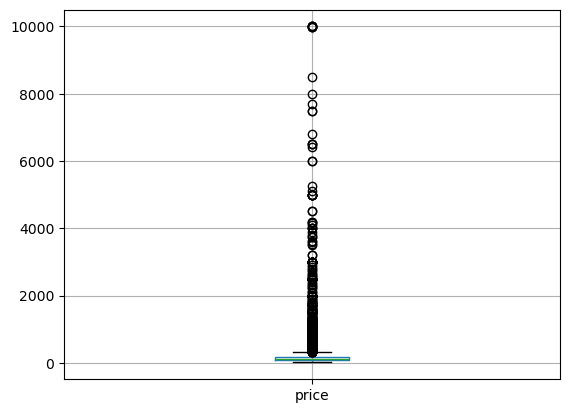

In [12]:
df.boxplot(column='price')
plt.show

In [13]:
df['price'].skew()

np.float64(19.119026764709606)

In [14]:
offset = df['price'].quantile(0.99)
df[df['price']>offset].describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,occupied_days,occupancy_rate,revpar
count,4.740000e+02,4.740000e+02,474.000000,474.000000,474.000000,474.000000,474.000000,250.000000,474.000000,474.000000,474.000000,474.000000,474.000000
mean,1.909181e+07,7.189693e+07,40.733351,-73.976866,1703.088608,12.175105,8.905063,0.922520,3.546414,182.770042,182.229958,0.499260,851.379094
std,1.195412e+07,8.460636e+07,0.044371,0.038132,1557.799196,36.184822,20.521774,1.161732,11.844079,149.453635,149.453635,0.409462,1272.625104
min,1.960100e+04,8.730000e+03,40.530760,-74.202950,800.000000,1.000000,0.000000,0.020000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,7.845750e+06,7.055854e+06,40.715265,-73.997838,900.000000,1.000000,0.000000,0.180000,1.000000,2.000000,13.000000,0.035616,44.508904
50%,2.004339e+07,2.824811e+07,40.736740,-73.983480,1033.000000,2.000000,1.000000,0.485000,1.000000,180.000000,185.000000,0.506849,604.931507
75%,3.058040e+07,1.253204e+08,40.760415,-73.964442,1799.750000,5.000000,8.000000,1.032500,2.000000,352.000000,363.000000,0.994521,1031.780822
max,3.645272e+07,2.740800e+08,40.886710,-73.741300,10000.000000,365.000000,177.000000,7.020000,121.000000,365.000000,365.000000,1.000000,10000.000000


In [15]:
df[
    (df['revpar'] > 4000) &
    (
        (df['room_type'] == 'Private room') |
        (df['room_type'] == 'Shared room')
    )
]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,occupied_days,occupancy_rate,revpar
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0,365,1.000000,10000.000000
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83,282,0.772603,7725.254795
37194,29547314,Apartment New York \nHell’s Kitchens,35303743,Patricia,Manhattan,Upper West Side,40.76835,-73.98367,Private room,6500,30,0,NaN,NaN,1,97,268,0.734247,4772.602740


In [16]:
df = df[
    ~(
        (df['room_type'] == 'Private room') &
        (df['revpar'] > 4000)
    )
]

In [17]:
df[
    (df['revpar'] > 4000) &
    (
        (df['room_type'] == 'Entire home/apt') 
    )
]

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,occupied_days,occupancy_rate,revpar
3720,2243699,"SuperBowl Penthouse Loft 3,000 sqft",1483320,Omri,Manhattan,Little Italy,40.71895,-73.99793,Entire home/apt,5250,1,0,NaN,NaN,1,0,365,1.000000,5250.000000
3774,2271504,SUPER BOWL Brooklyn Duplex Apt!!,11598359,Jonathan,Brooklyn,Clinton Hill,40.68766,-73.96439,Entire home/apt,6500,1,0,NaN,NaN,1,0,365,1.000000,6500.000000
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0,365,1.000000,9999.000000
15560,12520066,Luxury townhouse Greenwich Village,66240032,Linda,Manhattan,Greenwich Village,40.73046,-73.99562,Entire home/apt,6000,1,0,NaN,NaN,1,0,365,1.000000,6000.000000
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0,365,1.000000,10000.000000
25825,20654227,Fulton 2,100069033,Sarah-2,Brooklyn,Cypress Hills,40.68185,-73.88128,Entire home/apt,5000,2,4,2018-01-03,0.18,1,0,365,1.000000,5000.000000
26739,21238053,Broadway 1,153497815,Sarah-B,Brooklyn,Bedford-Stuyvesant,40.68742,-73.91957,Entire home/apt,5000,2,8,2017-12-09,0.38,1,0,365,1.000000,5000.000000
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83,282,0.772603,7726.027397
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.76824,-73.95989,Entire home/apt,7703,1,0,NaN,NaN,12,146,219,0.600000,4621.800000
29664,22780103,Park Avenue Mansion by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.78517,-73.95270,Entire home/apt,6419,1,0,NaN,NaN,12,45,320,0.876712,5627.616438


In [18]:
df = df[
    ~(
        (df['room_type'] == 'Entire home/apt') &
        (df['revpar'] > 9000)
    )
]

In [19]:
df[['price','revpar']].skew()

price     16.785393
revpar    16.368412
dtype: float64

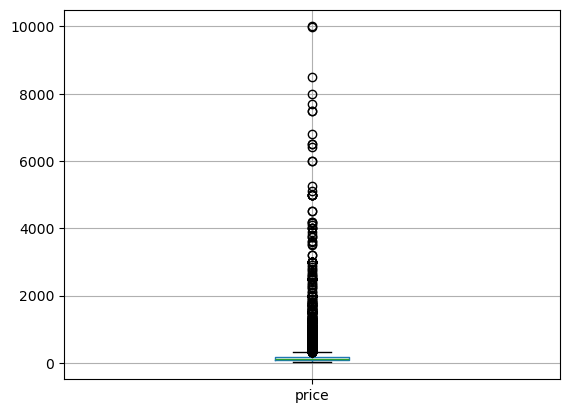

In [20]:
df.boxplot(column='price')
plt.show()

In [21]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,occupied_days,occupancy_rate,revpar
count,4.887900e+04,4.887900e+04,48879.000000,48879.000000,48879.000000,48879.000000,48879.000000,38829.000000,48879.000000,48879.000000,48879.000000,48879.000000,48879.000000
mean,1.901741e+07,6.762760e+07,40.728950,-73.952175,151.819391,7.025717,23.274085,1.373260,7.145257,112.787352,252.212648,0.690994,97.607951
std,1.098434e+07,7.861865e+07,0.054533,0.046160,221.196307,20.504475,44.553122,1.680427,32.957812,131.630950,131.630950,0.360633,143.656997
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,9.470616e+06,7.822033e+06,40.690095,-73.983080,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000,138.000000,0.378082,35.000000
50%,1.967610e+07,3.079724e+07,40.723080,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000,320.000000,0.876712,70.000000
75%,2.915303e+07,1.074344e+08,40.763115,-73.936290,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000,365.000000,1.000000,125.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,365.000000,1.000000,7726.027397


In [22]:
df['occupancy_rate'].describe()

count    48879.000000
mean         0.690994
std          0.360633
min          0.000000
25%          0.378082
50%          0.876712
75%          1.000000
max          1.000000
Name: occupancy_rate, dtype: float64

In [23]:
df['occupancy_rate'].quantile([0.25,0.5,0.75])

0.25    0.378082
0.50    0.876712
0.75    1.000000
Name: occupancy_rate, dtype: float64

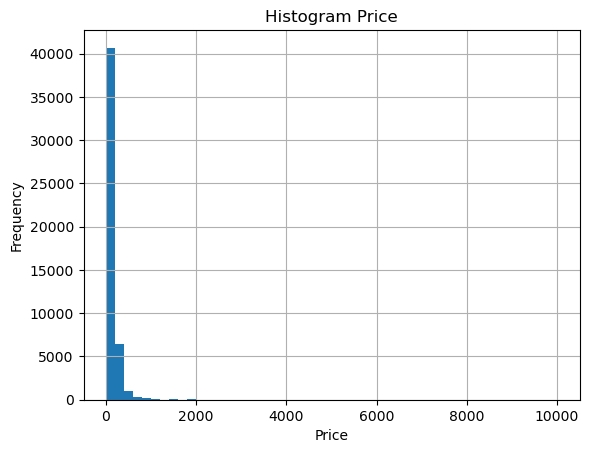

In [24]:
df['price'].hist(bins=50)

plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram Price')

plt.show()

In [25]:
df.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10050
reviews_per_month                 10050
calculated_host_listings_count        0
availability_365                      0
occupied_days                         0
occupancy_rate                        0
revpar                                0
dtype: int64

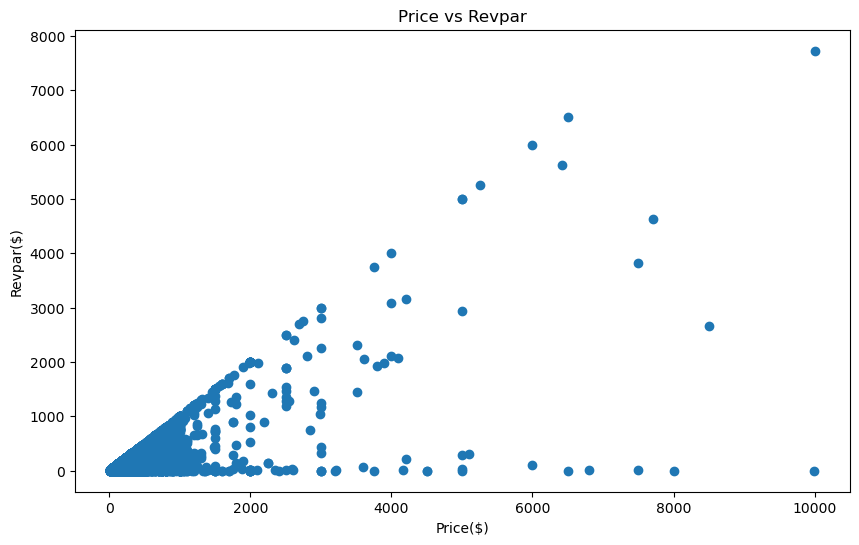

In [26]:
plt.figure (figsize=(10,6))
plt.scatter(
    df['price'],
    df['revpar']
)

plt.xlabel('Price($)')
plt.ylabel('Revpar($)')
plt.title('Price vs Revpar')

plt.show()
    

<Figure size 1000x600 with 0 Axes>

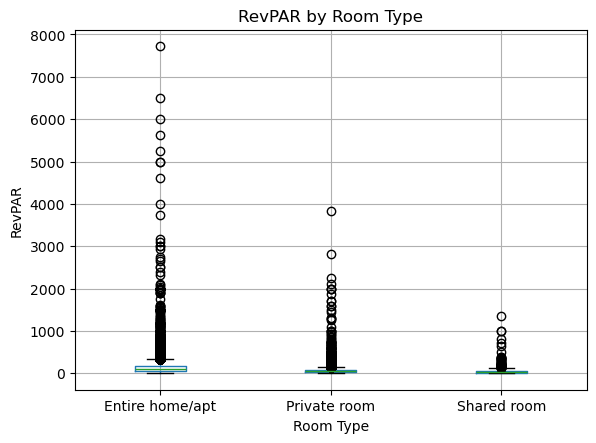

In [27]:
plt.figure(figsize=(10,6))

df.boxplot(column='revpar', by='room_type')

plt.title('RevPAR by Room Type')
plt.suptitle('')

plt.xlabel('Room Type')
plt.ylabel('RevPAR')

plt.show()

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48879 entries, 0 to 48894
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48879 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48879 non-null  int64  
 3   host_name                       48858 non-null  object 
 4   neighbourhood_group             48879 non-null  object 
 5   neighbourhood                   48879 non-null  object 
 6   latitude                        48879 non-null  float64
 7   longitude                       48879 non-null  float64
 8   room_type                       48879 non-null  object 
 9   price                           48879 non-null  int64  
 10  minimum_nights                  48879 non-null  int64  
 11  number_of_reviews               48879 non-null  int64  
 12  last_review                     38829

In [29]:
df['neighbourhood_group'].unique()

array(['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx'],
      dtype=object)

In [30]:
df['neighbourhood_group'].value_counts()

neighbourhood_group
Manhattan        21657
Brooklyn         20094
Queens            5665
Bronx             1090
Staten Island      373
Name: count, dtype: int64

In [31]:
df.groupby('neighbourhood')['neighbourhood_group'].nunique()

neighbourhood
Allerton           1
Arden Heights      1
Arrochar           1
Arverne            1
Astoria            1
                  ..
Windsor Terrace    1
Woodhaven          1
Woodlawn           1
Woodrow            1
Woodside           1
Name: neighbourhood_group, Length: 221, dtype: int64

In [32]:
problem = df.groupby('neighbourhood')['neighbourhood_group'].nunique()

problem[problem > 1]

Series([], Name: neighbourhood_group, dtype: int64)

In [34]:
manhattan = df[df['neighbourhood_group']=='Manhattan']['price']

brooklyn = df[df['neighbourhood_group']=='Brooklyn']['price']

queens = df[df['neighbourhood_group']=='Queens']['price']

bronx = df[df['neighbourhood_group']=='Bronx']['price']

staten_island = df[df['neighbourhood_group']=='Staten Island']['price']

In [37]:
from scipy.stats import kruskal
stat, p_value = kruskal(
    manhattan,
    brooklyn,
    queens,
    bronx,
    staten_island
)

print('Statistic:', stat)
print('P-value:', p_value)

Statistic: 7023.8727931185595
P-value: 0.0


In [39]:
borough_summary = (
    df.groupby('neighbourhood_group')
      .agg(
          median_price=('price', 'median'),
          median_revpar=('revpar', 'median'),
          listing_count=('id', 'count')
      )
      .reset_index()
)

borough_summary

,neighbourhood_group,median_price,median_revpar,listing_count
0,Bronx,65.0,32.342466,1090
1,Brooklyn,90.0,64.495890,20094
2,Manhattan,150.0,92.964384,21657
3,Queens,75.0,44.273973,5665
4,Staten Island,75.0,28.841096,373


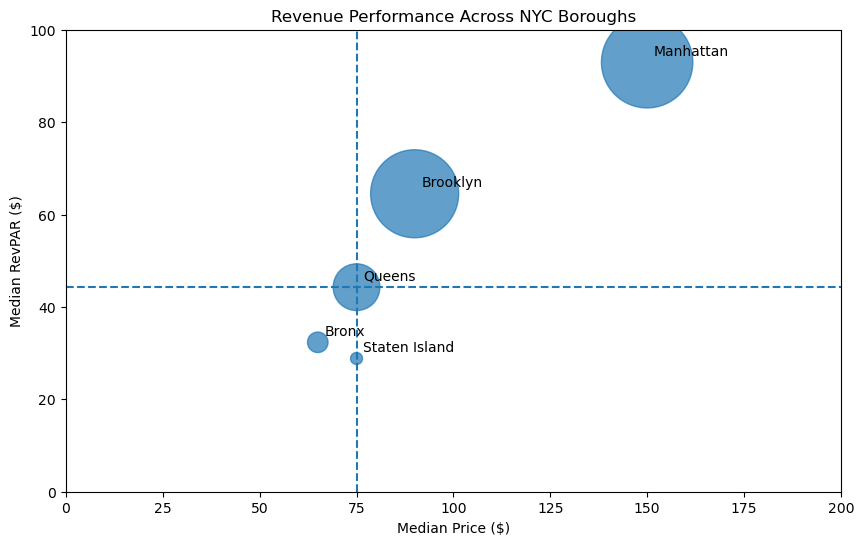

In [54]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(
    borough_summary['median_price'],
    borough_summary['median_revpar'],
    s=borough_summary['listing_count']/5,
    alpha=0.7
)

for _, row in borough_summary.iterrows():
    plt.annotate(
        row['neighbourhood_group'],
        (row['median_price'], row['median_revpar']),
        xytext=(5,5),
        textcoords='offset points'
    )

plt.xlabel('Median Price ($)')
plt.ylabel('Median RevPAR ($)')
plt.title('Revenue Performance Across NYC Boroughs')

plt.axvline(
    borough_summary['median_price'].median(),
    linestyle='--'
)

plt.axhline(
    borough_summary['median_revpar'].median(),
    linestyle='--'
)
plt.ylim(0,100)
plt.xlim(0,200)
plt.show()